Generated availability matrix using SCIP tool. For different carbon budget, fetch the final best accuracy

# Display Test Accuracy

In [1]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat

from matplotlib import pyplot as plt
from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

In [2]:
NON_IID, IID = "0.1", "100000"

In [3]:
def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test) 

                                        if os.path.exists(event_dir):
                                            # print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, "availability": av,
                                                "alpha": a, "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "test_loss": "Test/Loss",
                                                "train_accuracy": "Train/Metric",
                                                "train_loss": "Train/Loss",
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

In [4]:
main_folder = 'model_quality'

In [5]:
def modify_data(_df):
    tmp = _df.groupby(['algorithm', 'availability','lr', 'alpha']).test_accuracy.apply(np.vstack).to_frame().reset_index()
    tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
    tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
    tmp['std_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.std(axis=0))
    tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
    tmp['final_var_acc'] = tmp['var_test_acc'].apply(lambda x : x[-1])
    tmp['final_std_acc'] = tmp['std_test_acc'].apply(lambda x : x[-1])
    tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
    tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))
    return tmp

def get_plt(tmp, data_type=NON_IID, ft=True):
    # Filter and process data for FedAvg
    fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
    fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)

    # Filter and process data for FedVarp
    fedvarp = tmp.loc[(tmp['algorithm'] == 'fedvarp') & (tmp['alpha'] == data_type)]
    fedvarp['avail_mat'] = fedvarp['availability'].str.extract(r'alphaF-[\w-]*?(\d+\.\d+)cb').astype(float)

    # Plot
    plt.figure(figsize=(10, 8))

    # Plot for FedAvg with lr differentiation
    for lr_value in fed_avg['lr'].unique():
        subset = fed_avg[fed_avg['lr'] == lr_value].sort_values('avail_mat')
        plt.plot(
            subset['avail_mat'], subset['final_mean_acc'], 
            marker='o', label=f'FedAvg (lr={lr_value})'
        )
        plt.fill_between(
            subset['avail_mat'], 
            subset['final_mean_acc'] - subset['final_var_acc'], 
            subset['final_mean_acc'] + subset['final_var_acc'], 
            alpha=0.2
        )

    # Plot for FedVarp with lr differentiation
    for lr_value in fedvarp['lr'].unique():
        subset = fedvarp[fedvarp['lr'] == lr_value].sort_values('avail_mat')
        plt.plot(
            subset['avail_mat'], subset['final_mean_acc'], 
            marker='o', linestyle='--', label=f'FedVarp (lr={lr_value})'
        )
        plt.fill_between(
            subset['avail_mat'], 
            subset['final_mean_acc'] - subset['final_var_acc'], 
            subset['final_mean_acc'] + subset['final_var_acc'], 
            alpha=0.2
        )
        

    # Add labels and legend
    plt.xlabel('Carbon Budget', fontsize=12)
    plt.ylabel('Final Test Accuracy (with Variance)', fontsize=12)
    plt.title(f'{data_type} case {"with" if ft else "no"} ft', fontsize=14)
    plt.grid(visible=True, which='both')
    plt.minorticks_on()  # Enable minor ticks for finer granularity
    plt.ylim(0,1)
    plt.legend()
    plt.show()



# Analysis n rounds = 50

In [6]:
import os
from datetime import datetime, timedelta

def load_data(countries=None):
    """
    Loads the CI data in df_dict a dictionary where key=country, value=dataframe of CI data.
    Returns: df_dict
    The columns of each dataframe are datetime, CI_direct, CI_LA.
    The unit of the CI data is: gCO2eq/kWh.
    """

    # prepare links to the data csv files
    folder = "../building_availability_matrices/historical_data"
    _paths = {
        "Germany": os.path.join(folder, "DE_2022_hourly.csv"),
        "Austria": os.path.join(folder, "AT_2022_hourly.csv"),
        "Ireland": os.path.join(folder, "IE_2022_hourly.csv"),
        "Great Britain": os.path.join(folder, "GB_2022_hourly.csv"),
        "France": os.path.join(folder, "FR_2022_hourly.csv"),
        "Sweden": os.path.join(folder, "SE-SE3_2022_hourly.csv"),
        "Finland": os.path.join(folder, "FI_2022_hourly.csv"),
        "Belgium": os.path.join(folder, "BE_2022_hourly.csv"),
        "Brazil": os.path.join(folder, "BR_2022_hourly.csv"),
        "Denmark": os.path.join(folder, "DK_2022_hourly.csv"),
        "Estonia": os.path.join(folder, "EE_2022_hourly.csv"),
        "Spain": os.path.join(folder, "ES_2022_hourly.csv"),
        "Hungary": os.path.join(folder, "HU_2022_hourly.csv"),
        "Singapore": os.path.join(folder, "SG_2022_hourly.csv"),
        "Japan": os.path.join(folder, "JP_2022_hourly.csv"),
        "South Africa": os.path.join(folder, "ZA_2022_hourly.csv"),
        "Peru": os.path.join(folder, "PE_2022_hourly.csv"),
        "Croatia": os.path.join(folder, "HR_2022_hourly.csv"),
    }
    # loading the data in a pandas dataframe
    df_dict = {}
    usecols = [
        "Datetime (UTC)",
        "Carbon Intensity gCO₂eq/kWh (direct)",
        "Carbon Intensity gCO₂eq/kWh (LCA)",
    ]

    for key in countries if countries else _paths.keys():
        try:
            df_dict[key] = pd.read_csv(
                _paths[key], usecols=usecols, parse_dates=["Datetime (UTC)"]
            )
            df_dict[key] = df_dict[key].rename(
                columns={
                    "Datetime (UTC)": "datetime",
                    "Carbon Intensity gCO₂eq/kWh (direct)": "CI_direct",
                    "Carbon Intensity gCO₂eq/kWh (LCA)": "CI_LCA",
                }
            )
        except KeyError:
            print(f"Data for country {key} not present")
            continue

    return df_dict

In [7]:
countries=["Belgium", "Ireland", "Germany", "France", "Great Britain", "Finland", "Sweden"]
n_rounds = 50
dfs = load_data(countries)

start_time = datetime(2022, 1, 1, 0, 0)


CI_matrix = pd.DataFrame(
            index=countries, columns=[i for i in range(n_rounds)]
        )
for country in countries:
    CI_values = dfs[country][
            dfs[country]["datetime"].between(start_time, start_time + timedelta(hours=n_rounds - 1))
        ]["CI_direct"].values
    CI_matrix.loc[country, :] = CI_values

In [8]:
power = 300 / 1000  # in kiloWatts
round_duration = 1  # in hours: this is duration of a FL training round
GHG_matrix = CI_matrix * power * round_duration / 1000
total_cb = GHG_matrix.sum().sum()

In [9]:
# For 3 steps of fine tuning
carbon_budget_considered = GHG_matrix.sum().cumsum().to_numpy().take([44,39,34,29,24,19,14,9,8,4,3])
perc_cb_saved = np.insert(1 - carbon_budget_considered/total_cb, 0,0.0)


In [10]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-199sl-1cb-3ft alphaF50-199sl-2cb-3ft alphaF50-197sl-3cb-3ft alphaF50-197sl-4cb-3ft alphaF50-197sl-5cb-3ft alphaF50-197sl-6cb-3ft alphaF50-196sl-7cb-3ft alphaF50-197sl-8cb-3ft alphaF50-197sl-9cb-3ft alphaF50-197sl-10cb-3ft alphaF50-196sl-11cb-3ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

2025-05-13 20:53:54.803306: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747149834.830308   68021 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747149834.844988   68021 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747149834.869026   68021 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747149834.869046   68021 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747149834.869048   68021 computation_placer.cc:177] computation placer alr

In [11]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')

# Extract avail_mat
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(50).astype(int)
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)

In [27]:
alpha_test_acc = tmp['final_mean_acc'] * 100
base_test_acc = results_df.loc[0, 'test_accuracy'].take([50,45,40,35,30,25,20,15,10,9,5,4]) *100

In [32]:
base_test_acc

array([98.8499999 , 98.79000187, 98.76000285, 98.71000051, 98.53000045,
       98.50000143, 98.3099997 , 97.93000221, 97.31000066, 97.24000096,
       95.31000257, 94.37000155])

In [28]:
alpha_test_acc

0     98.850000
1     63.725001
2     98.240000
3     83.339998
4     98.954999
5     98.954999
6     98.995000
7     98.715001
8     53.029998
9     10.185000
10    99.120000
11    99.059999
Name: final_mean_acc, dtype: float64

In [31]:
results_df

,algorithm,availability,alpha,participation,max_test_accuracy,final_test_accuracy,test_accuracy,test_loss,train_accuracy,train_loss,seed,lr,event,n_clients,biased
0,fedavg,alphaF50-0.0cb-3ft,0.5,known,98.860002,98.850000,"[0.12150000035762787, 0.8429999947547913, 0.90...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
1,fedavg,alphaF50-199sl-1cb-3ft,0.5,known,99.129999,99.129999,"[0.12150000035762787, 0.6057999730110168, 0.15...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
2,fedavg,alphaF50-199sl-2cb-3ft,0.5,known,99.040002,99.030000,"[0.12150000035762787, 0.5940999984741211, 0.14...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
3,fedavg,alphaF50-197sl-3cb-3ft,0.5,known,99.089998,99.040002,"[0.12150000035762787, 0.633899986743927, 0.378...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
4,fedavg,alphaF50-197sl-4cb-3ft,0.5,known,98.900002,98.879999,"[0.12150000035762787, 0.3547999858856201, 0.66...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
5,fedavg,alphaF50-197sl-5cb-3ft,0.5,known,98.920000,98.900002,"[0.12150000035762787, 0.34950000047683716, 0.6...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
6,fedavg,alphaF50-197sl-6cb-3ft,0.5,known,98.809999,98.760003,"[0.12150000035762787, 0.40619999170303345, 0.7...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
7,fedavg,alphaF50-196sl-7cb-3ft,0.5,known,98.310000,98.310000,"[0.12150000035762787, 0.4381999969482422, 0.47...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
8,fedavg,alphaF50-197sl-8cb-3ft,0.5,known,97.280002,10.280000,"[0.12150000035762787, 0.3458000123500824, 0.43...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2
9,fedavg,alphaF50-197sl-9cb-3ft,0.5,known,96.450001,10.090000,"[0.12150000035762787, 0.34869998693466187, 0.4...",Test/Loss,Train/Metric,Train/Loss,42,5e-2,global,7,2


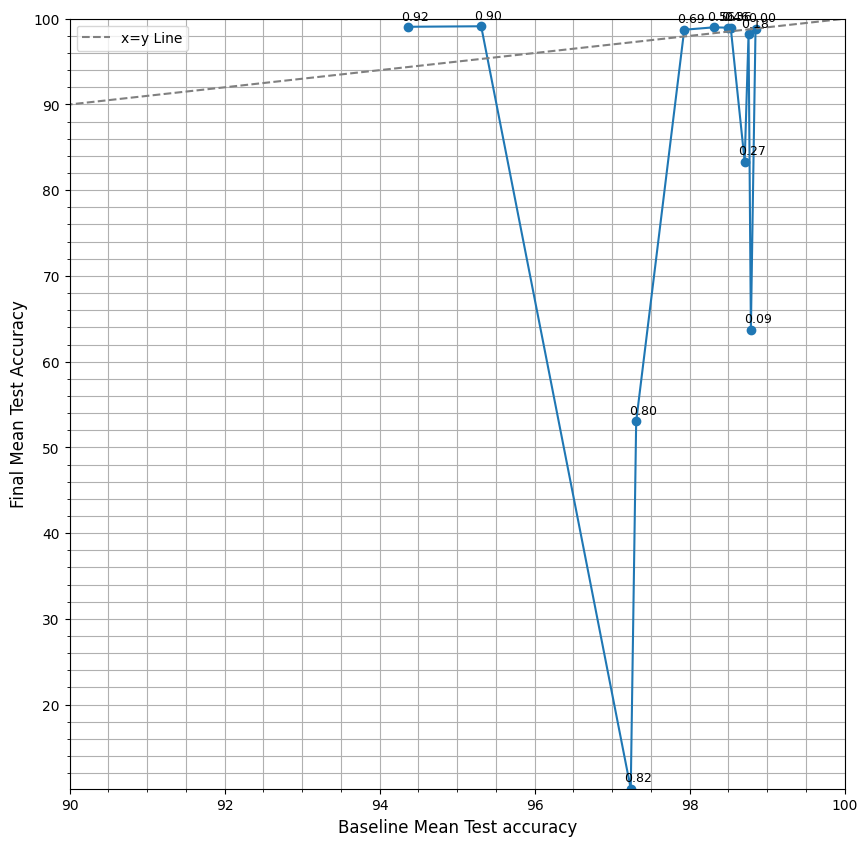

In [30]:
plt.figure(figsize=(10,10))
plt.plot(
    base_test_acc,
    alpha_test_acc,
    marker='o', 
)

for i in range(len(base_test_acc)):
    plt.annotate(
        f'{perc_cb_saved[i]:.2f}', 
        (base_test_acc[i],alpha_test_acc[i]), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9
    )

x_min = min(min(base_test_acc), min(alpha_test_acc))


plt.plot([x_min, 100.0], [x_min, 100.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(90.0, 100.0)
plt.ylim(x_min, 100.0)
# plt.title(f"Heterogeneity {data_type}; fine-tuning: 1; # rounds= 5")
plt.legend()
plt.savefig("../../50_0.5_1ft.png")
plt.show()

In [16]:
from functools import reduce
dfs = [
    fed_avg.loc[fed_avg['slack_time'] == i]
    .sort_values('avail_mat')[['avail_mat', 'final_mean_acc']]
    .rename(columns={'final_mean_acc': f'{i}'})
    for i in [51,52,53,54,55,56,57,58,59,60,70,80,90,100,120,140,160,180,200]
]

# Merge all DataFrames on 'avail_mat' iteratively
result = reduce(lambda left, right: pd.merge(left, right, on='avail_mat', how='outer'), dfs)


In [51]:
result.set_index("avail_mat").to_csv("../../3.csv")

In [ ]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42","78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-1cb-3ft alphaF50-2cb-3ft alphaF50-3cb-3ft alphaF50-4cb-3ft alphaF50-5cb-3ft alphaF50-6cb-3ft alphaF50-7cb-3ft alphaF50-8cb-3ft alphaF50-9cb-3ft alphaF50-10cb-3ft alphaF50-11cb-3ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

2025-04-17 20:27:06.805836: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744901826.825121   12036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744901826.830890   12036 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744901826.845107   12036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744901826.845157   12036 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744901826.845159   12036 computation_placer.cc:177] computation placer alr

In [16]:
alpha_test_acc = modify_data(results_df)['final_mean_acc']
base_test_acc = results_df.loc[0, 'test_accuracy'].take([50,45,40,35,30,25,20,15,10,9,5,4]) *100

ValueError: x and y must be the same size

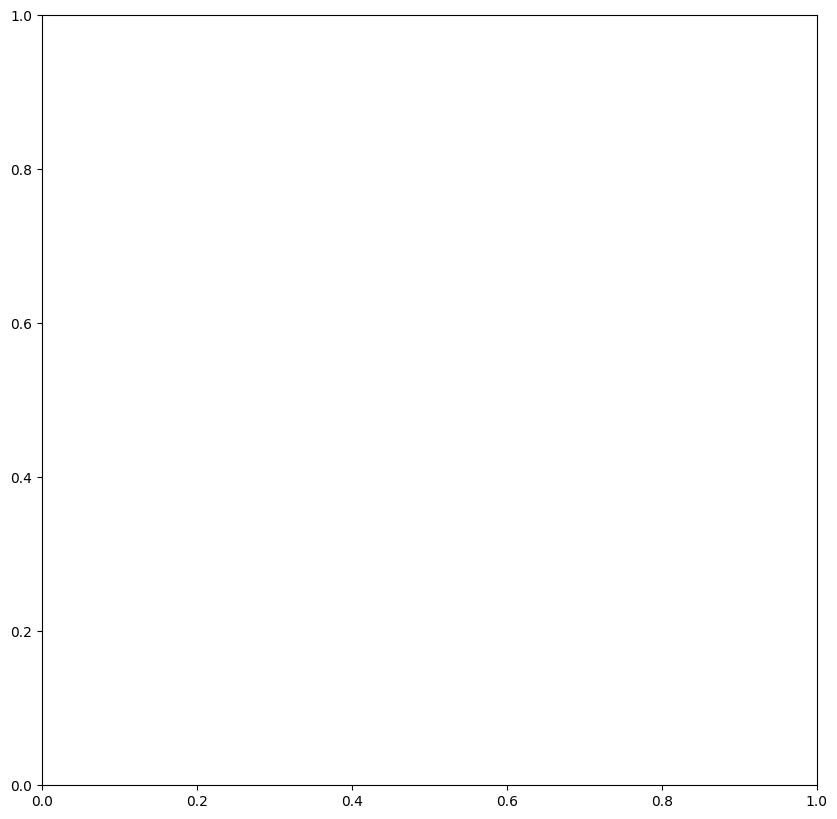

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(
    base_test_acc,
    alpha_test_acc,
    marker='o', 
)

for i in range(len(base_test_acc)):
    plt.annotate(
        f'{perc_cb_saved[i]:.2f}', 
        (base_test_acc[i],alpha_test_acc[i]), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9
    )

x_min = min(min(base_test_acc), min(alpha_test_acc))


plt.plot([x_min, 100.0], [x_min, 100.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 100.0)
plt.ylim(x_min, 100.0)
# plt.title(f"Heterogeneity {data_type}; fine-tuning: 1; # rounds= 5")
plt.legend()
plt.savefig("../../50_0.5_1ft.png")
plt.show()

### Fine tuning step = 1

In [10]:
# For 3 steps of fine tuning
carbon_budget_considered = GHG_matrix.sum().cumsum().to_numpy().take([44,39,34,29,24,19,14,9,4,3,2,1])
perc_cb_saved = np.insert(1 - carbon_budget_considered/total_cb, 0,0.0)

In [ ]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42","78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-1cb-1ft alphaF50-2cb-1ft alphaF50-3cb-1ft alphaF50-5cb-1ft alphaF50-6cb-1ft alphaF50-7cb-1ft alphaF50-8cb-1ft alphaF50-9cb-1ft alphaF50-10cb-1ft alphaF50-11cb-1ft alphaF50-12cb-1ft alphaF50-4cb-1ft".split(
            " "
        )
    ),
    n_rounds="100",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

In [21]:
alpha_test_acc = results_df['final_test_accuracy']
base_test_acc = results_df.loc[0, 'test_accuracy'].take([50,45,40,35,30,25,20,15,10,5,4,3,2]) *100

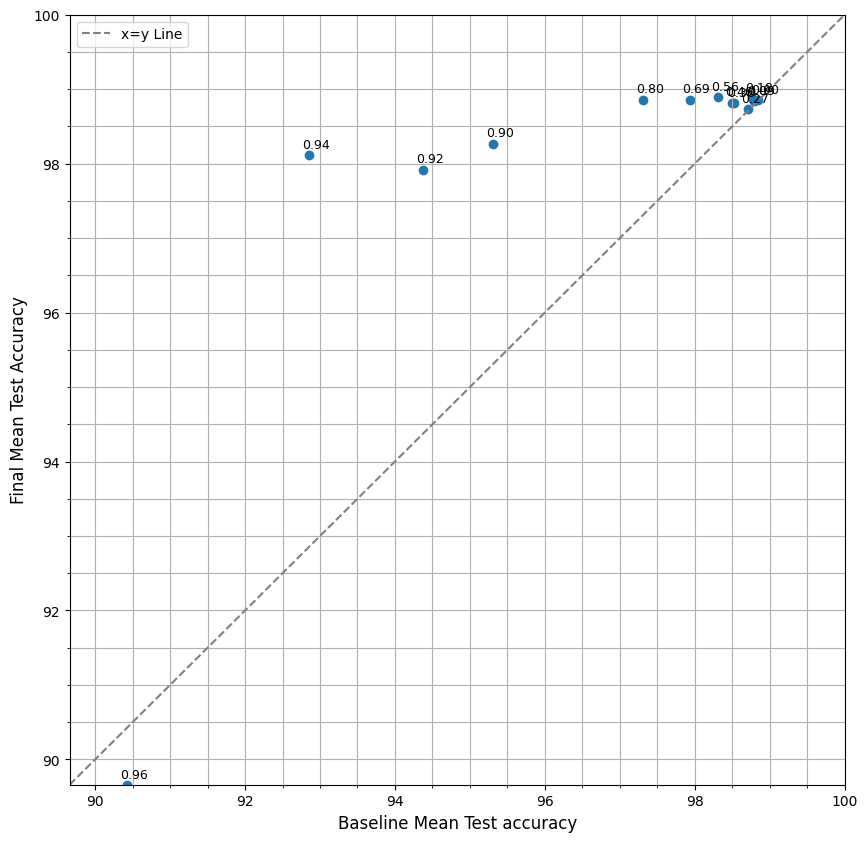

In [81]:
plt.figure(figsize=(10,10))
plt.scatter(
    base_test_acc,
    alpha_test_acc,
    marker='o', 
)

for i in range(len(base_test_acc)):
    plt.annotate(
        f'{perc_cb_saved[i]:.2f}', 
        (base_test_acc[i],alpha_test_acc[i]), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=9
    )

x_min = min(min(base_test_acc), min(alpha_test_acc))


plt.plot([x_min, 100.0], [x_min, 100.0], color='gray', linestyle='--', label='x=y Line')

plt.xlabel('Baseline Mean Test accuracy', fontsize=12)
plt.ylabel('Final Mean Test Accuracy', fontsize=12)
plt.grid(visible=True, which='both')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min, 100.0)
plt.ylim(x_min, 100.0)
# plt.title(f"Heterogeneity {data_type}; fine-tuning: 1; # rounds= 5")
plt.legend()
plt.savefig("../../50_0.5_1ft.png")
plt.show()

In [ ]:
config = ExperimentConfig(
    base_path=os.path.join("..", "logs"),
    experiment="mnist_server",
    seeds=["42", "78", "84"],
    algorithms=["fedavg"],
    events=["global"],
    lr_list=["5e-2"],
    alphas=["0.5"],
    n_clients_list=["7"],
    availabilities=list(
        "alphaF50-0.0cb-3ft alphaF50-1cb-1ft alphaF50-2cb-1ft alphaF50-3cb-1ft alphaF50-4cb-1ft alphaF50-5cb-1ft alphaF50-6cb-1ft alphaF50-7cb-1ft alphaF50-8cb-1ft alphaF50-9cb-1ft alphaF50-10cb-1ft alphaF50-11cb-1ft alphaF50-12cb-1ft alphaF50-200sl-10cb-1ft alphaF50-200sl-11cb-1ft alphaF50-200sl-12cb-1ft alphaF50-200sl-1cb-1ft alphaF50-200sl-2cb-1ft alphaF50-200sl-3cb-1ft alphaF50-200sl-4cb-1ft alphaF50-200sl-5cb-1ft alphaF50-200sl-6cb-1ft alphaF50-200sl-7cb-1ft alphaF50-200sl-8cb-1ft alphaF50-200sl-9cb-1ft alphaF50-180sl-10cb-1ft alphaF50-180sl-11cb-1ft alphaF50-180sl-12cb-1ft alphaF50-180sl-1cb-1ft alphaF50-180sl-2cb-1ft alphaF50-180sl-3cb-1ft alphaF50-180sl-4cb-1ft alphaF50-180sl-5cb-1ft alphaF50-180sl-6cb-1ft alphaF50-180sl-7cb-1ft alphaF50-180sl-8cb-1ft alphaF50-180sl-9cb-1ft alphaF50-160sl-10cb-1ft alphaF50-160sl-11cb-1ft alphaF50-160sl-12cb-1ft alphaF50-160sl-1cb-1ft alphaF50-160sl-2cb-1ft alphaF50-160sl-3cb-1ft alphaF50-160sl-4cb-1ft alphaF50-160sl-5cb-1ft alphaF50-160sl-6cb-1ft alphaF50-160sl-7cb-1ft alphaF50-160sl-8cb-1ft alphaF50-160sl-9cb-1ft alphaF50-140sl-10cb-1ft alphaF50-140sl-11cb-1ft alphaF50-140sl-12cb-1ft alphaF50-140sl-1cb-1ft alphaF50-140sl-2cb-1ft alphaF50-140sl-3cb-1ft alphaF50-140sl-4cb-1ft alphaF50-140sl-5cb-1ft alphaF50-140sl-6cb-1ft alphaF50-140sl-7cb-1ft alphaF50-140sl-8cb-1ft alphaF50-140sl-9cb-1ft alphaF50-120sl-10cb-1ft alphaF50-120sl-11cb-1ft alphaF50-120sl-12cb-1ft alphaF50-120sl-1cb-1ft alphaF50-120sl-2cb-1ft alphaF50-120sl-3cb-1ft alphaF50-120sl-4cb-1ft alphaF50-120sl-5cb-1ft alphaF50-120sl-6cb-1ft alphaF50-120sl-7cb-1ft alphaF50-120sl-8cb-1ft alphaF50-120sl-9cb-1ft alphaF50-100sl-10cb-1ft alphaF50-100sl-11cb-1ft alphaF50-100sl-12cb-1ft alphaF50-100sl-1cb-1ft alphaF50-100sl-2cb-1ft alphaF50-100sl-3cb-1ft alphaF50-100sl-4cb-1ft alphaF50-100sl-5cb-1ft alphaF50-100sl-6cb-1ft alphaF50-100sl-7cb-1ft alphaF50-100sl-8cb-1ft alphaF50-100sl-9cb-1ft alphaF50-90sl-10cb-1ft alphaF50-90sl-11cb-1ft alphaF50-90sl-1cb-1ft alphaF50-90sl-2cb-1ft alphaF50-90sl-3cb-1ft alphaF50-90sl-4cb-1ft alphaF50-90sl-5cb-1ft alphaF50-90sl-6cb-1ft alphaF50-90sl-7cb-1ft alphaF50-90sl-8cb-1ft alphaF50-90sl-9cb-1ft alphaF50-80sl-10cb-1ft alphaF50-80sl-11cb-1ft alphaF50-80sl-12cb-1ft alphaF50-80sl-1cb-1ft alphaF50-80sl-2cb-1ft alphaF50-80sl-3cb-1ft alphaF50-80sl-4cb-1ft alphaF50-80sl-5cb-1ft alphaF50-80sl-6cb-1ft alphaF50-80sl-7cb-1ft alphaF50-80sl-8cb-1ft alphaF50-80sl-9cb-1ft alphaF50-70sl-10cb-1ft alphaF50-70sl-11cb-1ft alphaF50-70sl-12cb-1ft alphaF50-70sl-1cb-1ft alphaF50-70sl-2cb-1ft alphaF50-70sl-3cb-1ft alphaF50-70sl-4cb-1ft alphaF50-70sl-5cb-1ft alphaF50-70sl-6cb-1ft alphaF50-70sl-7cb-1ft alphaF50-70sl-8cb-1ft alphaF50-70sl-9cb-1ft alphaF50-60sl-10cb-1ft alphaF50-60sl-11cb-1ft alphaF50-60sl-12cb-1ft alphaF50-60sl-1cb-1ft alphaF50-60sl-2cb-1ft alphaF50-60sl-3cb-1ft alphaF50-60sl-4cb-1ft alphaF50-60sl-5cb-1ft alphaF50-60sl-6cb-1ft alphaF50-60sl-7cb-1ft alphaF50-60sl-8cb-1ft alphaF50-60sl-9cb-1ft alphaF50-59sl-10cb-1ft alphaF50-59sl-11cb-1ft alphaF50-59sl-12cb-1ft alphaF50-59sl-1cb-1ft alphaF50-59sl-2cb-1ft alphaF50-59sl-3cb-1ft alphaF50-59sl-4cb-1ft alphaF50-59sl-5cb-1ft alphaF50-59sl-6cb-1ft alphaF50-59sl-7cb-1ft alphaF50-59sl-8cb-1ft alphaF50-59sl-9cb-1ft alphaF50-58sl-10cb-1ft alphaF50-58sl-11cb-1ft alphaF50-58sl-12cb-1ft alphaF50-58sl-1cb-1ft alphaF50-58sl-2cb-1ft alphaF50-58sl-3cb-1ft alphaF50-58sl-4cb-1ft alphaF50-58sl-5cb-1ft alphaF50-58sl-6cb-1ft alphaF50-58sl-7cb-1ft alphaF50-58sl-8cb-1ft alphaF50-58sl-9cb-1ft alphaF50-57sl-10cb-1ft alphaF50-57sl-11cb-1ft alphaF50-57sl-12cb-1ft alphaF50-57sl-1cb-1ft alphaF50-57sl-2cb-1ft alphaF50-57sl-3cb-1ft alphaF50-57sl-4cb-1ft alphaF50-57sl-5cb-1ft alphaF50-57sl-6cb-1ft alphaF50-57sl-7cb-1ft alphaF50-57sl-8cb-1ft alphaF50-57sl-9cb-1ft alphaF50-56sl-10cb-1ft alphaF50-56sl-11cb-1ft alphaF50-56sl-12cb-1ft alphaF50-56sl-1cb-1ft alphaF50-56sl-2cb-1ft alphaF50-56sl-3cb-1ft alphaF50-56sl-4cb-1ft alphaF50-56sl-5cb-1ft alphaF50-56sl-6cb-1ft alphaF50-56sl-7cb-1ft alphaF50-56sl-8cb-1ft alphaF50-56sl-9cb-1ft alphaF50-55sl-10cb-1ft alphaF50-55sl-11cb-1ft alphaF50-55sl-12cb-1ft alphaF50-55sl-1cb-1ft alphaF50-55sl-2cb-1ft alphaF50-55sl-3cb-1ft alphaF50-55sl-4cb-1ft alphaF50-55sl-5cb-1ft alphaF50-55sl-6cb-1ft alphaF50-55sl-7cb-1ft alphaF50-55sl-8cb-1ft alphaF50-55sl-9cb-1ft alphaF50-54sl-10cb-1ft alphaF50-54sl-11cb-1ft alphaF50-54sl-12cb-1ft alphaF50-54sl-1cb-1ft alphaF50-54sl-2cb-1ft alphaF50-54sl-3cb-1ft alphaF50-54sl-4cb-1ft alphaF50-54sl-5cb-1ft alphaF50-54sl-6cb-1ft alphaF50-54sl-7cb-1ft alphaF50-54sl-8cb-1ft alphaF50-54sl-9cb-1ft alphaF50-53sl-10cb-1ft alphaF50-53sl-11cb-1ft alphaF50-53sl-12cb-1ft alphaF50-53sl-1cb-1ft alphaF50-53sl-2cb-1ft alphaF50-53sl-3cb-1ft alphaF50-53sl-4cb-1ft alphaF50-53sl-5cb-1ft alphaF50-53sl-6cb-1ft alphaF50-53sl-7cb-1ft alphaF50-53sl-8cb-1ft alphaF50-53sl-9cb-1ft alphaF50-52sl-10cb-1ft alphaF50-52sl-11cb-1ft alphaF50-52sl-12cb-1ft alphaF50-52sl-1cb-1ft alphaF50-52sl-2cb-1ft alphaF50-52sl-3cb-1ft alphaF50-52sl-4cb-1ft alphaF50-52sl-5cb-1ft alphaF50-52sl-6cb-1ft alphaF50-52sl-7cb-1ft alphaF50-52sl-8cb-1ft alphaF50-52sl-9cb-1ft alphaF50-51sl-10cb-1ft alphaF50-51sl-11cb-1ft alphaF50-51sl-12cb-1ft alphaF50-51sl-1cb-1ft alphaF50-51sl-2cb-1ft alphaF50-51sl-3cb-1ft alphaF50-51sl-4cb-1ft alphaF50-51sl-5cb-1ft alphaF50-51sl-6cb-1ft alphaF50-51sl-7cb-1ft alphaF50-51sl-8cb-1ft alphaF50-51sl-9cb-1ft".split(
            " "
        )
    ),
    n_rounds="50",
    participations=["known"],
    biased_list=["2"],
    train_test="train",
)

results_df = get_exp_stats(config)

2025-04-18 16:18:07.356737: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744973287.917102   16368 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744973288.046422   16368 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744973289.710049   16368 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744973289.710110   16368 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744973289.710115   16368 computation_placer.cc:177] computation placer alr

In [12]:
tmp = modify_data(results_df)
data_type = "0.5"
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg') & (tmp['alpha'] == data_type)]
fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')

# Extract avail_mat
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(50).astype(int)
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)

In [13]:
100 - perc_cb_saved*100

array([100.0, 90.82381954238241, 81.99884401082006, 73.07155573023836,
       63.66685933152999, 54.24474602917717, 43.51738222396906,
       31.16096764000956, 20.380489985280406, 9.688268251142503,
       7.652401760186194, 5.728928243898295, 3.831657149022419],
      dtype=object)

In [14]:
fed_avg.loc[fed_avg['slack_time']==50].sort_values("avail_mat")[['avail_mat','final_mean_acc', 'final_std_acc']]

,avail_mat,final_mean_acc,final_std_acc
0,0,0.988500,0.000000
64,1,0.989067,0.000531
77,2,0.989100,0.000245
78,3,0.988533,0.000881
79,4,0.988333,0.000330
188,5,0.987933,0.000602
201,6,0.988933,0.000287
214,7,0.988967,0.000262
227,8,0.988600,0.000653
239,9,0.982900,0.000216


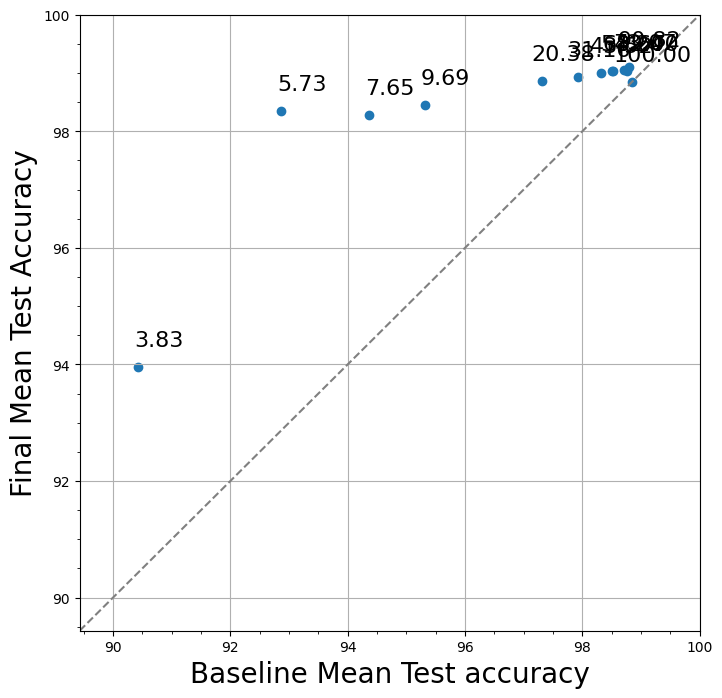

In [31]:
_tmp = fed_avg.loc[fed_avg.groupby('avail_mat')['final_mean_acc'].idxmax()]


plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc,
    _tmp['final_mean_acc'].values*100,
    marker='o', 
)

for i, val in enumerate(_tmp[['final_mean_acc', 'slack_time']].values):
    plt.annotate(
        # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
        f'{100 - 100*perc_cb_saved[i]:.2f}', 
        (base_test_acc[i],val[0]*100), 
        xytext=(15, 15), 
        textcoords="offset points", 
        ha='center', 
        fontsize=16
    )
    

       


x_min = min(min(base_test_acc), min(_tmp['final_mean_acc'].values*100))


plt.plot([x_min-1, 100.0], [x_min-1, 100.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-1, 100.0)
plt.ylim(x_min-1, 100.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()

In [18]:
alpha_test_acc_50 = fed_avg.loc[fed_avg['slack_time']==50].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100
alpha_test_acc_slack = {
    51: fed_avg.loc[fed_avg['slack_time']==51].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    52: fed_avg.loc[fed_avg['slack_time']==52].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    53: fed_avg.loc[fed_avg['slack_time']==53].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    54: fed_avg.loc[fed_avg['slack_time']==54].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    55: fed_avg.loc[fed_avg['slack_time']==55].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    56: fed_avg.loc[fed_avg['slack_time']==56].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    57: fed_avg.loc[fed_avg['slack_time']==57].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    58: fed_avg.loc[fed_avg['slack_time']==58].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    59: fed_avg.loc[fed_avg['slack_time']==59].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    60: fed_avg.loc[fed_avg['slack_time']==60].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    70: fed_avg.loc[fed_avg['slack_time']==70].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    80: fed_avg.loc[fed_avg['slack_time']==80].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    90: fed_avg.loc[fed_avg['slack_time']==90].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    100: fed_avg.loc[fed_avg['slack_time']==100].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    120: fed_avg.loc[fed_avg['slack_time']==120].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    140: fed_avg.loc[fed_avg['slack_time']==140].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    160: fed_avg.loc[fed_avg['slack_time']==160].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    180: fed_avg.loc[fed_avg['slack_time']==180].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100,
    200: fed_avg.loc[fed_avg['slack_time']==200].sort_values("avail_mat")['final_mean_acc'].to_numpy()*100
}
base_test_acc = results_df.loc[0, 'test_accuracy'].take([50,45,40,35,30,25,20,15,10,5,4,3,2])*100

In [29]:
pd.DataFrame.from_dict(alpha_test_acc_slack).to_csv("../1ft.csv")